In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [2]:
base_path = r"C:\kdt_0900_osh\ml\resource\datasets"
file_name = r"social_ads.csv"

file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## 1단계. 데이터 전처리

In [4]:
# 수치형 : Age, EstimatedSalary
# 분류형 : Gender, Perchased

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
ads_df = df.drop("User ID", axis=1)
ads_df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [7]:
ads_df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

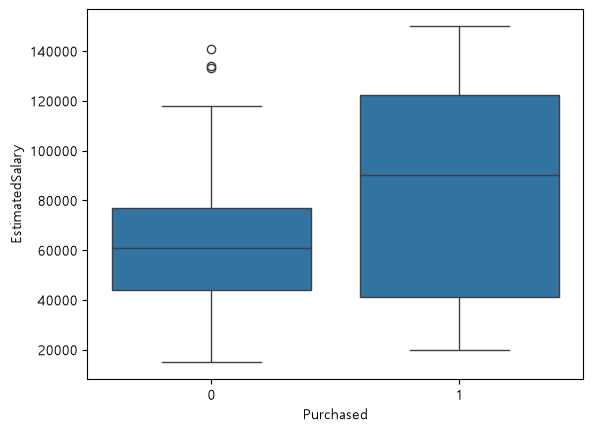

In [8]:
sns.boxplot(ads_df, x="Purchased", y="EstimatedSalary")
plt.show()

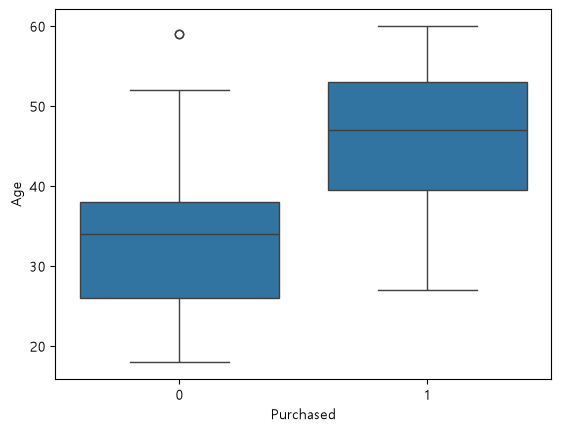

In [9]:
sns.boxplot(ads_df, x="Purchased", y="Age")
plt.show()

In [10]:
ads_df.head(1)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0


In [11]:
# 원 핫 인코딩 가능한 형태로 바꿈
ads_df = pd.get_dummies(ads_df, columns=["Gender"], dtype=int, drop_first=True)
ads_df

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1
...,...,...,...,...
395,46,41000,1,0
396,51,23000,1,1
397,50,20000,1,0
398,36,33000,0,1


In [12]:
X = ads_df.drop("Purchased", axis=1)
y = ads_df["Purchased"]

In [13]:
X.columns = ["Age","Salary","Gender"]
X.head()

,Age,Salary,Gender
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1


## 데이터 누수
- 데이터셋을 나누고 스케일링을 해야하는 이유: 데이터셋을 나누기 전에 전체 데이터를 스케일링하면  
  모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련 데이터셋에 야금야금 스며들어서 데이터 누수가 발생한다.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2단계. 모델 준비

In [16]:
# Salary 연봉
X_train_salary = X_train_scaled[:, [1]]
X_test_salary = X_test_scaled[:, [1]]

In [17]:
# 선형회귀 모델(weight * x) + bias
# weight : 가중치
# bias : 절편
lr = LinearRegression()

In [18]:
lr.fit(X_train_salary, y_train)

LinearRegression()

In [19]:
print(f"선형 모델의 정확도: {lr.score(X_train_salary, y_train)}")

선형 모델의 정확도: 0.1408930349620512


## 결론: 쓰레기

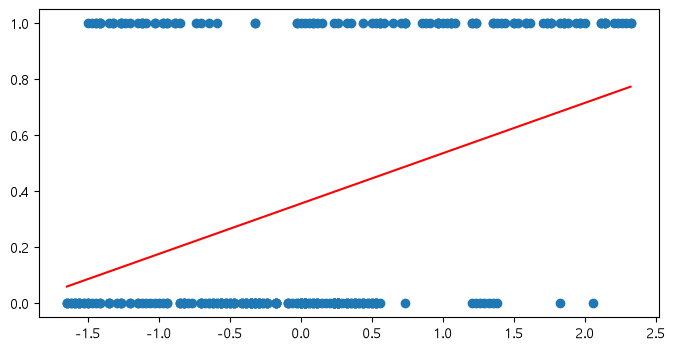

In [20]:
plt.figure(figsize=(8,4))
plt.scatter(X_train_salary, y_train)
x_line = np.linspace(X_train_salary.min(), X_train_salary.max(), 100).reshape(-1,1)
y_line = lr.predict(x_line)
plt.plot(x_line, y_line, color="red")
plt.show()

## 모델 준비

In [21]:
lr = LogisticRegression()

## 모델 학습

In [22]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [23]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0])

## 모델 평가
<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

### 과적합(overfitting)
- 머신러닝 과적합은 모델이 학습 데이터에만 지나치게 최적화되는 현상을 의미한다.  
  현제 데이터셋에 지나치게 맞춰지게 되면, 새로운 데이터가 들어왔을 때 예측능력이 크게 떨어질 수 있다.  
  이런 현상을 과적합이라고 한다.

In [24]:
print(f"훈련 데이터 점수: {lr.score(X_train_scaled, y_train)}")
print(f"테스트 데이터 점수: {accuracy_score(y_pred, y_test)}")

훈련 데이터 점수: 0.853125
테스트 데이터 점수: 0.7875


In [25]:
lr.coef_[0]
# 각 컬럼의 가중치

array([2.39487483, 1.16153043, 0.37388932])

In [26]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef",ascending=False)

In [27]:
coef_df

,Feature,Coef
0,Age,2.394875
1,Salary,1.161530
2,Gender,0.373889


In [28]:
"""
    소셜 상품 구매 셋에서는 연봉보다 나이가 구매 여부에 영향을 많이 끼친 것으로 파악된다.
"""
None

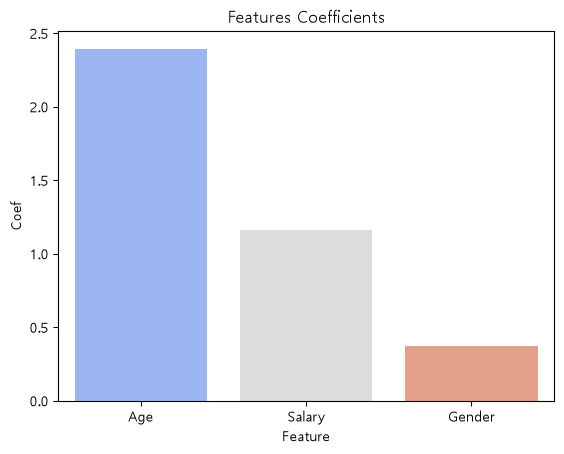

In [29]:
sns.barplot(coef_df, x="Feature", y="Coef", hue="Feature", palette="coolwarm")
plt.title("Features Coefficients")
plt.show()

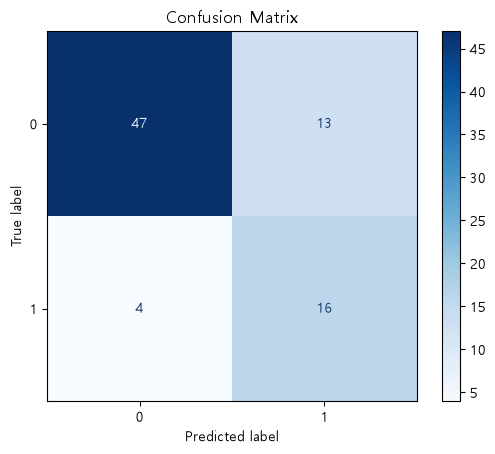

In [30]:
cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [31]:
file_name = r"admission_predict.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         400 non-null    int64  
 1   Serial No.         400 non-null    int64  
 2   GRE Score          400 non-null    int64  
 3   TOEFL Score        400 non-null    int64  
 4   University Rating  400 non-null    int64  
 5   SOP                400 non-null    float64
 6   LOR                400 non-null    float64
 7   CGPA               400 non-null    float64
 8   Research           400 non-null    int64  
 9   Chance of Admit    400 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 31.4 KB


In [33]:
df.describe()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.450000
std,115.614301,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.498117
min,0.000000,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.000000
25%,99.750000,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.000000
50%,199.500000,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.000000
75%,299.250000,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,1.000000
max,399.000000,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,1.000000


In [34]:
# 분류형: Research, Chance of Admit, University Rating
# 수치형: GRE Score, TOEFL Score, SOP, LOR, CGPA

## 1단계. 데이터 전처리

In [35]:
uni_df = df.drop(["Unnamed: 0", "Serial No."], axis=1)
uni_df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,1
396,325,107,3,3.0,3.5,9.11,1,1
397,330,116,4,5.0,4.5,9.45,1,1
398,312,103,3,3.5,4.0,8.78,0,0


<Axes: xlabel='Chance of Admit ', ylabel='Research'>

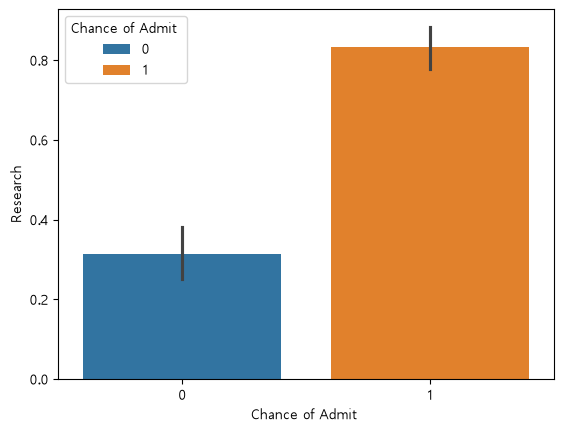

In [36]:
sns.barplot(data=uni_df, x="Chance of Admit ", y="Research", hue="Chance of Admit ")

<Axes: xlabel='Chance of Admit ', ylabel='CGPA'>

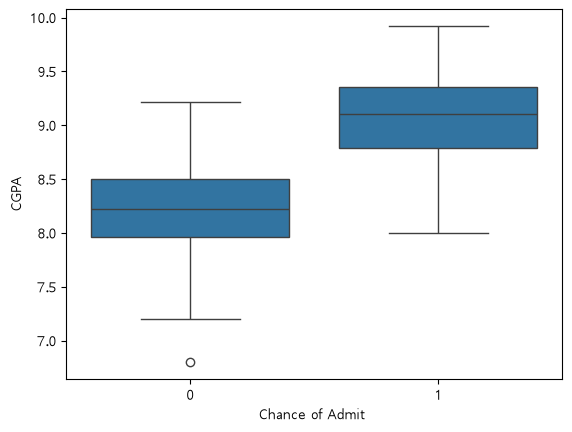

In [37]:
sns.boxplot(data=uni_df, x="Chance of Admit ", y="CGPA")

<Axes: xlabel='Chance of Admit ', ylabel='LOR '>

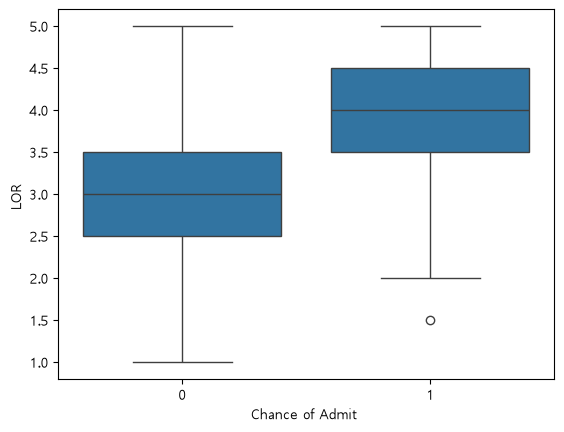

In [38]:
sns.boxplot(data=uni_df, x="Chance of Admit ", y="LOR ")

<Axes: xlabel='Chance of Admit ', ylabel='SOP'>

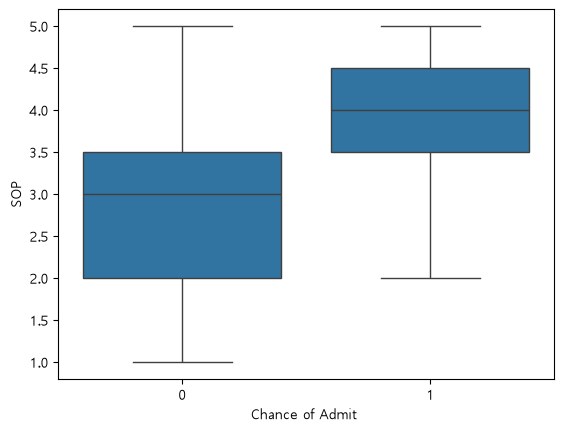

In [39]:
sns.boxplot(data=uni_df, x="Chance of Admit ", y="SOP")

(0.0, 6.0)

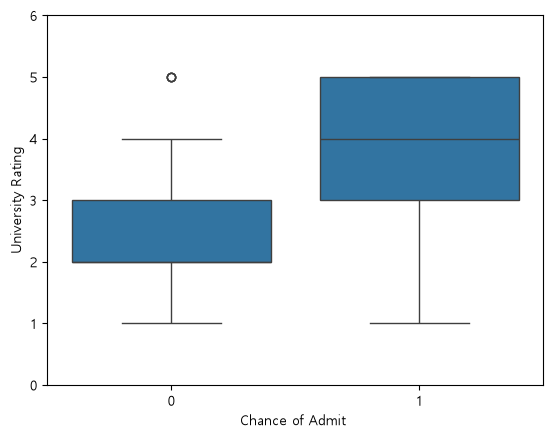

In [40]:
sns.boxplot(data=uni_df, x="Chance of Admit ", y="University Rating")
plt.ylim(0,6)

<Axes: xlabel='Chance of Admit ', ylabel='TOEFL Score'>

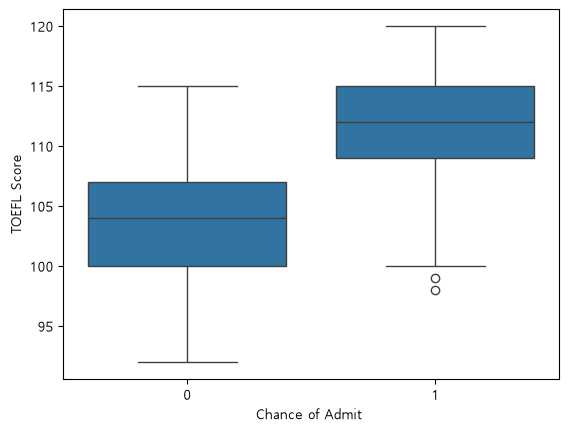

In [41]:
sns.boxplot(data=uni_df, x="Chance of Admit ", y="TOEFL Score")

<Axes: xlabel='Chance of Admit ', ylabel='GRE Score'>

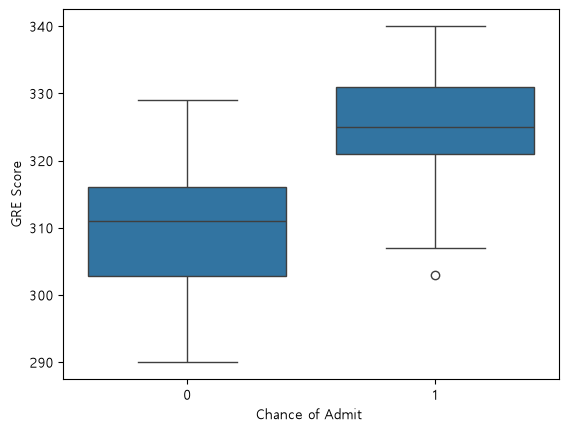

In [42]:
sns.boxplot(data=uni_df, x="Chance of Admit ", y="GRE Score")

In [43]:
uni_df.corr()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.686138
TOEFL Score,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.672465
University Rating,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.638983
SOP,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.612152
LOR,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.557481
CGPA,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.737307
Research,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.519441
Chance of Admit,0.686138,0.672465,0.638983,0.612152,0.557481,0.737307,0.519441,1.000000


## 데이터 분할

In [44]:
X = uni_df.drop("Chance of Admit ", axis=1)

In [45]:
y = uni_df["Chance of Admit "]

In [46]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research'],
      dtype='str')


[np.float64(4.61551616678161),
 np.float64(4.288959013746899),
 np.float64(2.9196056618253414),
 np.float64(3.075503721954348),
 np.float64(2.431258484869441),
 np.float64(5.207402545736424),
 np.float64(1.5433119011502867)]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

## 스캐일링

In [48]:
scaler = StandardScaler()

In [49]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 모델 준비

In [50]:
lr = LogisticRegression()

## 모델 학습

In [51]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [52]:
y_pred = lr.predict(X_test_scaled)

## 모델 평가

In [53]:
lr.coef_

array([[0.66240298, 0.32488882, 0.50617208, 0.62748009, 0.14616093,
        1.75286373, 0.35710735]])

In [54]:
X.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research'],
      dtype='str')

In [55]:
accuracy_score(y_pred, y_test)

0.8875

In [56]:
lr.score(X_test_scaled, y_test)

0.8875

In [57]:
lr.score(X_train_scaled, y_train)

0.8875

In [58]:
cm = confusion_matrix(y_test, y_pred)

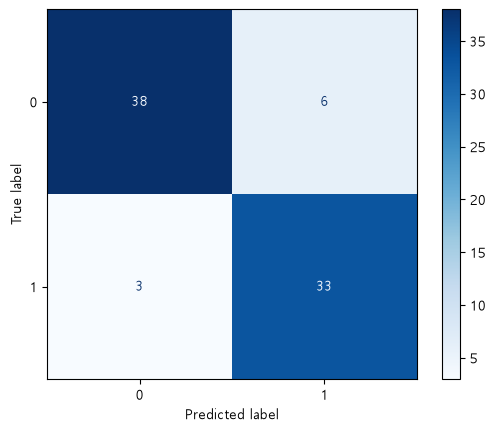

In [59]:
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")

## 1단계. 데이터 준비

In [60]:
uni_df = df.drop(["Unnamed: 0", "Serial No."], axis=1)

In [61]:
uni_df.columns = [i.strip() for i in uni_df.columns]

In [62]:
uni_df.columns = uni_df.columns.str.strip()

In [63]:
uni_df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance of Admit'],
      dtype='str')

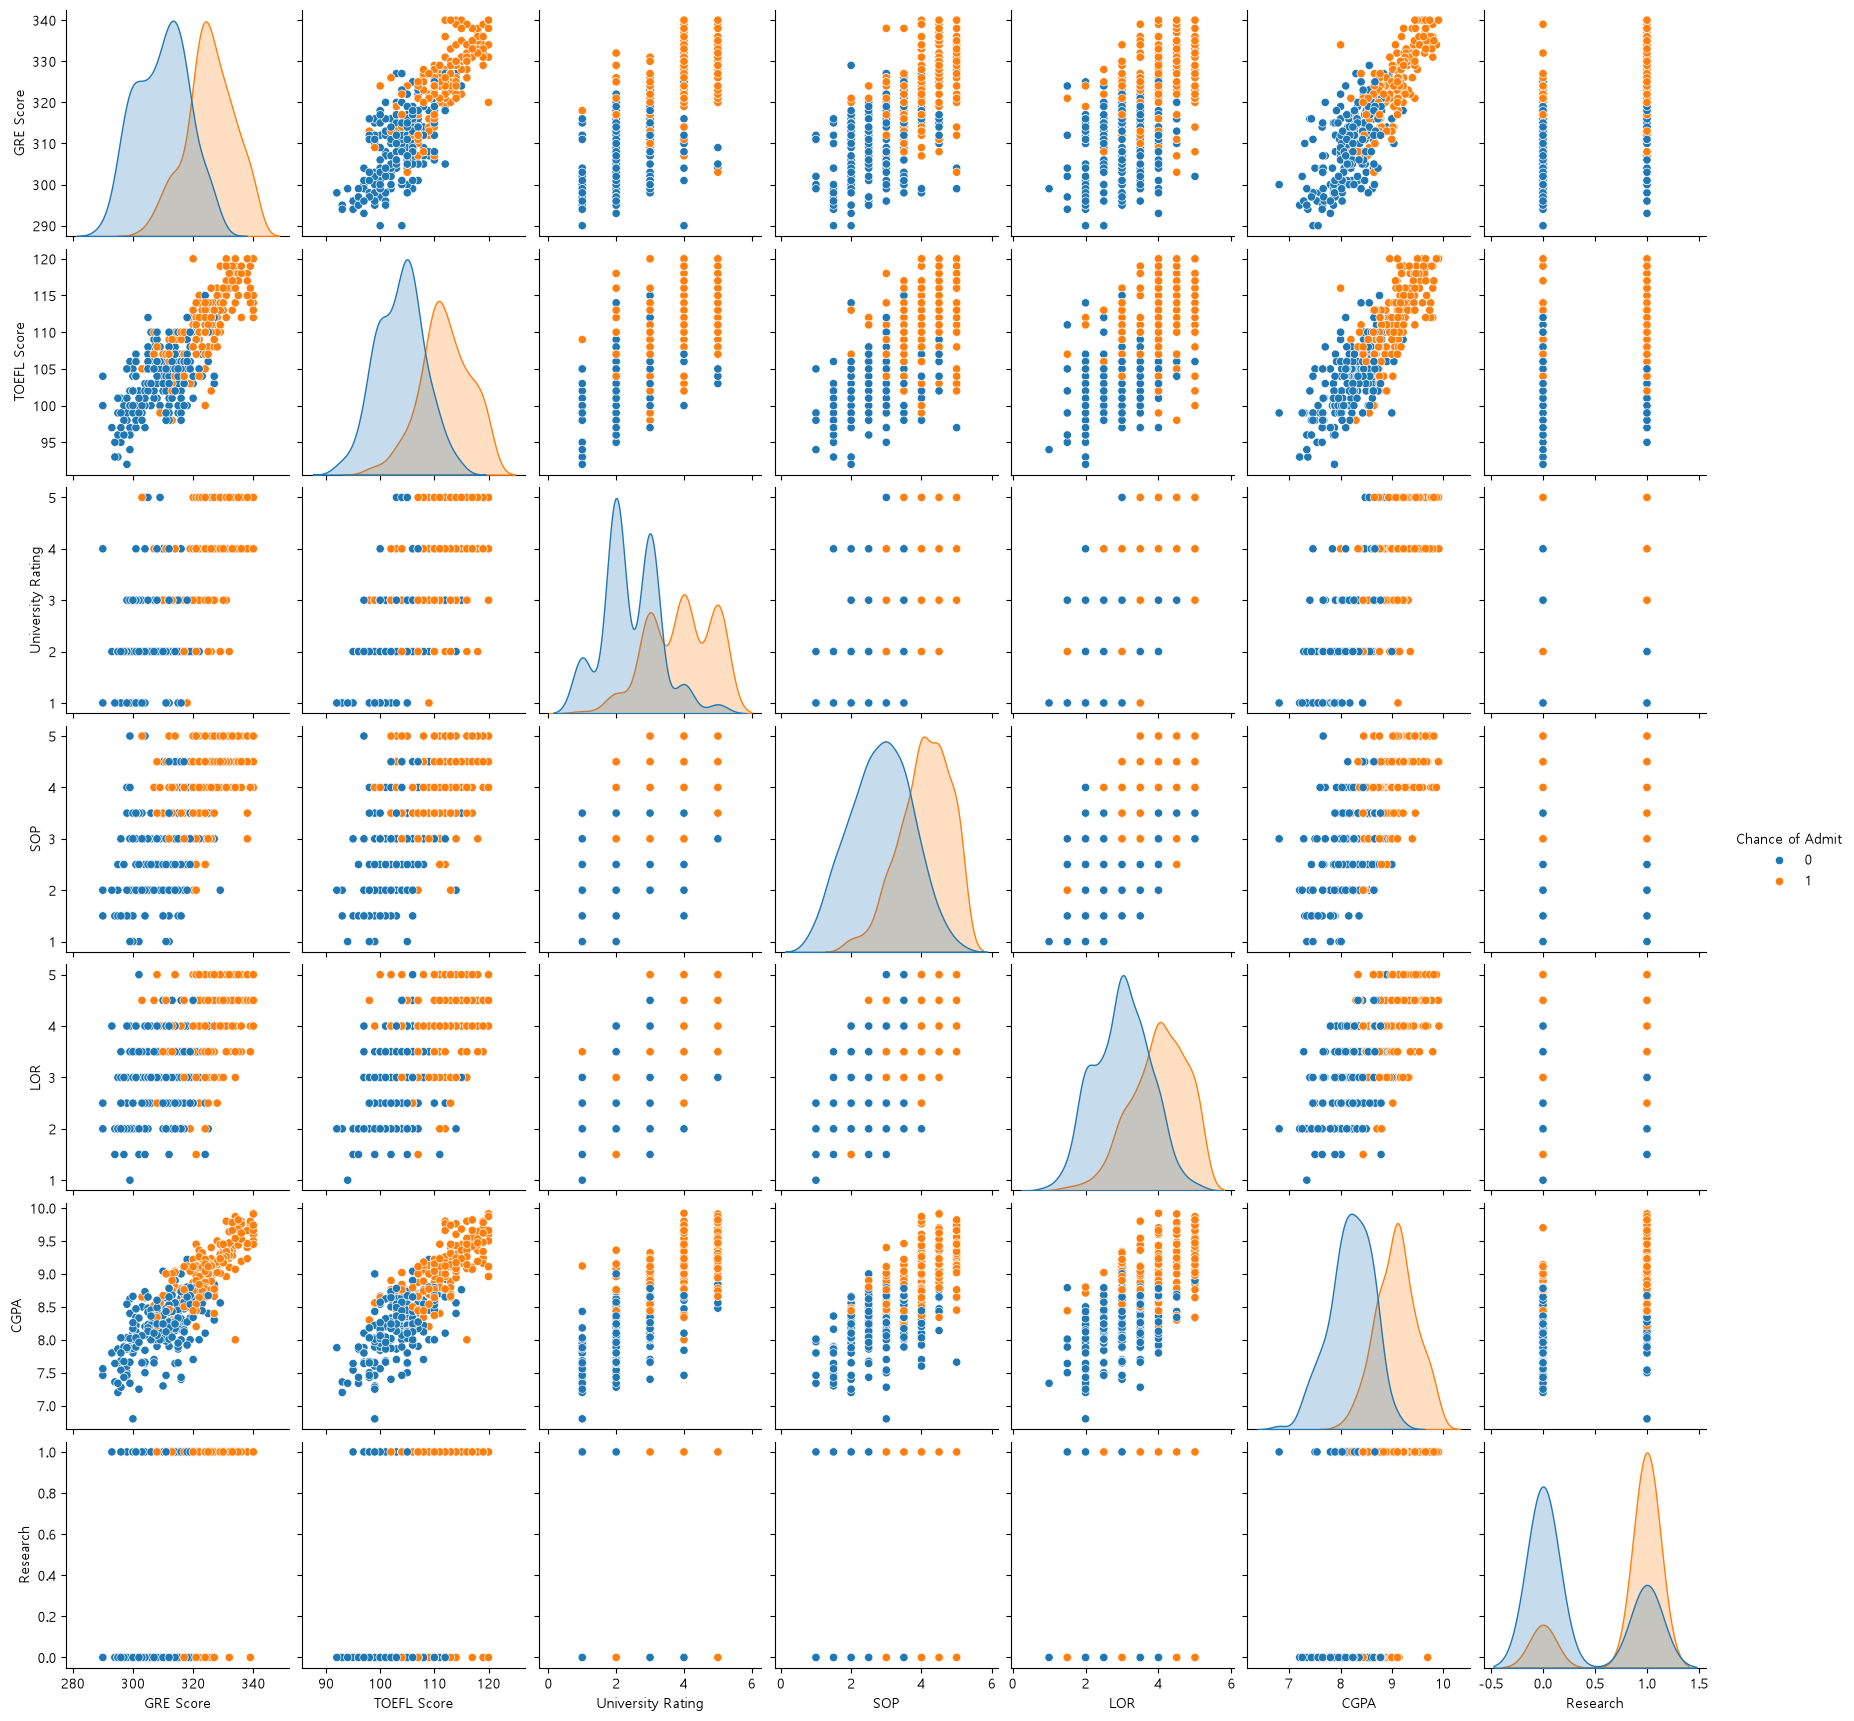

In [64]:
sns.pairplot(uni_df, hue="Chance of Admit")

## 2단계. 스캐일링

In [65]:
X = uni_df.drop("Chance of Admit", axis=1)
y = uni_df["Chance of Admit"]


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

In [67]:
scaler = StandardScaler()

In [68]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3단계. 모델 준비

In [69]:
lr = LogisticRegression()

## 4단계. 모델 학습

In [70]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

## 5단계. 모델 예측

In [71]:
y_pred = lr.predict(X_test_scaled)

## 6단계. 모델 평가

In [72]:
print(f"훈련 정확도: {lr.score(X_train_scaled,y_train)}")
print(f"테스트 정확도: {accuracy_score(y_test, y_pred)}")

훈련 정확도: 0.8875
테스트 정확도: 0.8875


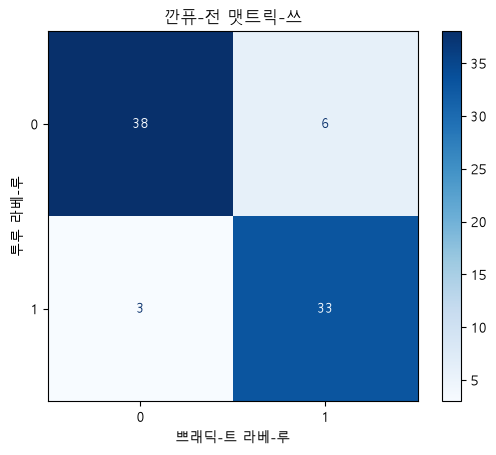

In [73]:
cm = confusion_matrix(y_test,y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("깐퓨-전 맷트릭-쓰")
plt.xlabel("쁘래딕-트 라베-루")
plt.ylabel("투루 라베-루")
plt.show()

## 1단계

In [74]:
admission_df = df.drop(["Unnamed: 0", "Serial No."], axis=1)
admission_df.columns = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Target']

In [75]:
admission_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          400 non-null    int64  
 1   TOEFL Score        400 non-null    int64  
 2   University Rating  400 non-null    int64  
 3   SOP                400 non-null    float64
 4   LOR                400 non-null    float64
 5   CGPA               400 non-null    float64
 6   Research           400 non-null    int64  
 7   Target             400 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 25.1 KB


In [76]:
admission_df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Target
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.450000
std,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.498117
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.000000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.000000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.000000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,1.000000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,1.000000


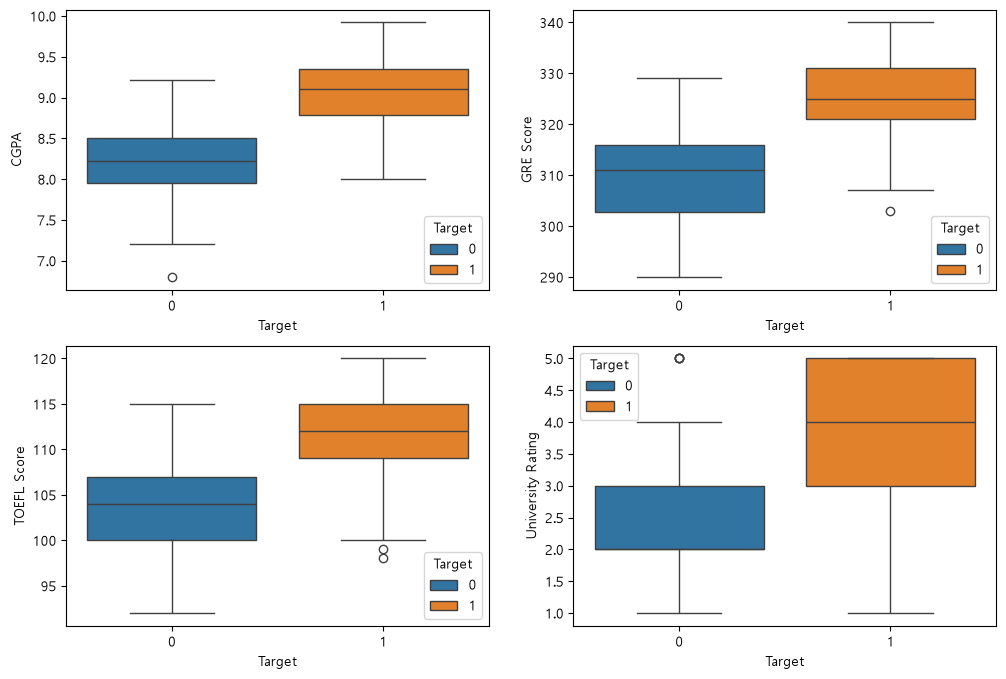

In [77]:
features = ["CGPA", "GRE Score", "TOEFL Score","University Rating"]
plt.figure(figsize=(12,8))
for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)
    sns.boxplot(admission_df,x="Target", y=feature, hue="Target")

plt.show()

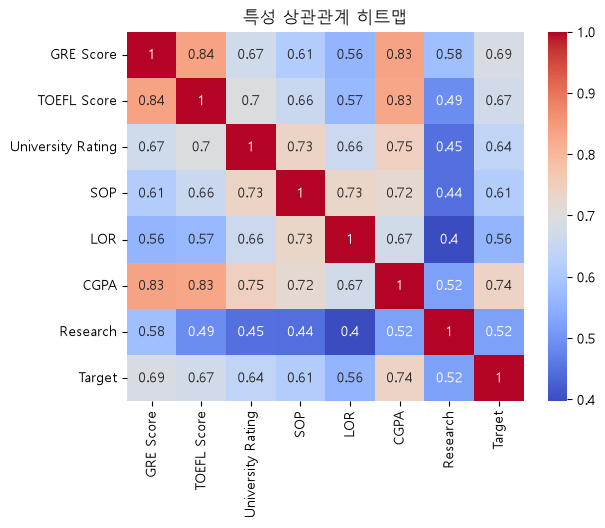

In [78]:
corr = admission_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("특성 상관관계 히트맵")
plt.show()

In [79]:
X = admission_df.drop("Target", axis=1)
y = admission_df["Target"]

In [80]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)
print(X.columns)

[np.float64(4.61551616678161), np.float64(4.288959013746899), np.float64(2.9196056618253414), np.float64(3.075503721954348), np.float64(2.431258484869441), np.float64(5.207402545736424), np.float64(1.5433119011502867)]
Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research'],
      dtype='str')


In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(320, 7) (80, 7) (320,) (80,)


## 데이터 표준화

In [82]:
scaler = StandardScaler()

In [83]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error  # 예측하는 모델의 평가 지표(잔차의 평균)를 보여줌(기존까지 했던 평가는 분류 모델의 지표)

## 규제(regularization)
- 머신러닝 모델이 train 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것
- 선형회귀 모델의 경우 특성에 곱해지는 계수 또는 기울기의 크기를 작게 만드는 일이다.
- 쉽게 말하자면 선형회귀 모델의 성능을 끌어올리기 위한 방법이다.


#### 1) 릿지(ridge)
- 계수를 제곱한 값을 기준으로 규제를 적용한다. (일반적으로 선호)
- 조금 넘을 때는 벌금이 적지만, 과속이 심해질수록 벌금이 제곱으로 폭발하도록 설계된다.  
  즉, 작은 값으로 연산하여 값이 폭발하는 것을 방지함.
- 예를 들어 $z = (2.5 \times 100) + b = 250 + b$를
- $z = (0.008 \times 100) + b = 0.8 + b$


#### 2) 라쏘(lasso)
- 계수의 절댓값을 기준으로 규제를 적용한다. 영향을 주지 않는 가중치는 과감하게 빼버림 (가중치가 작든 크든 줄어드는 비율이 일정)
- $z = $$z = w_1 \cdot (\text{연봉}) + w_2 \cdot (\text{나이}) + w_3 \cdot (\text{성별}) + b$$
- $z = $$z = w_1 \cdot (\text{연봉}) + 0 \cdot (\text{나이}) + 0 \cdot (\text{성별}) + b$$

In [85]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01)
}

result = []
coef_df = pd.DataFrame(index=X.columns)

for name, model in models.items():
    # 학습
    model.fit(X_train_scaled, y_train)

    # 예측
    y_pred = model.predict(X_test_scaled)

    # 평가
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    y_pred_class = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_class)

    result.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "Acurracy": acc
    })

    coef_df[name] = model.coef_

In [86]:
coef_df

,LinearRegression,Ridge,Lasso
GRE Score,0.076086,0.076236,0.075305
TOEFL Score,0.009755,0.010982,0.008198
University Rating,0.069660,0.069725,0.066634
SOP,0.055002,0.054779,0.048769
LOR,-0.004585,-0.003801,0.000000
CGPA,0.170626,0.168599,0.169111
Research,0.064450,0.064335,0.058810


In [87]:
result_df = pd.DataFrame(result)
result_df

,Model,MSE,RMSE,Acurracy
0,LinearRegression,0.101292,0.318264,0.8625
1,Ridge,0.101213,0.318139,0.8625
2,Lasso,0.101332,0.318326,0.8875


In [88]:
coef_df.sort_values(by="LinearRegression", ascending=False)

,LinearRegression,Ridge,Lasso
CGPA,0.170626,0.168599,0.169111
GRE Score,0.076086,0.076236,0.075305
University Rating,0.069660,0.069725,0.066634
Research,0.064450,0.064335,0.058810
SOP,0.055002,0.054779,0.048769
TOEFL Score,0.009755,0.010982,0.008198
LOR,-0.004585,-0.003801,0.000000


In [89]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

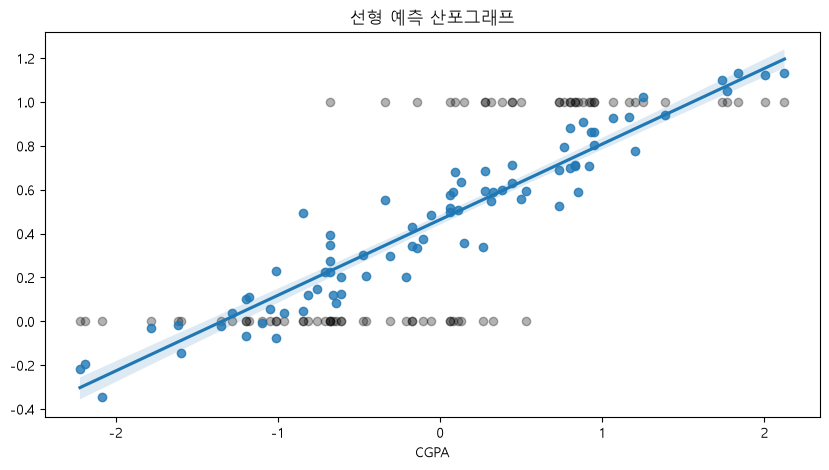

In [90]:
plt.figure(figsize=(10,5))

plt.scatter(X_test_scaled_df["CGPA"], y_test, color="black", alpha=0.3, label="Actual")
sns.regplot(x=X_test_scaled_df["CGPA"], y=model.predict(X_test_scaled))

plt.title("선형 예측 산포그래프")
plt.show()

#### 원래 쓰레기 모델이 나와야 하는데, 운이 좋아서 X_test 데이터의 선 밑에 있는 0인 데이터 개수와 선 위에 있는 1인 데이터 개수가 많아서 정답률이 높게 나옴.

In [91]:
lr = LogisticRegression()

In [92]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [93]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [94]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_percent = y_prob * 100
# 0이 정답일 확률과 1이 정답일 확률

for i, proba in enumerate(y_prob_percent[:20], 1):
    print(f"샘플 {i}번의 합격 확률 : {proba:.2f}%")

샘플 1번의 합격 확률 : 98.86%
샘플 2번의 합격 확률 : 5.62%
샘플 3번의 합격 확률 : 6.88%
샘플 4번의 합격 확률 : 0.09%
샘플 5번의 합격 확률 : 0.24%
샘플 6번의 합격 확률 : 14.38%
샘플 7번의 합격 확률 : 24.86%
샘플 8번의 합격 확률 : 0.24%
샘플 9번의 합격 확률 : 6.15%
샘플 10번의 합격 확률 : 99.88%
샘플 11번의 합격 확률 : 80.96%
샘플 12번의 합격 확률 : 0.35%
샘플 13번의 합격 확률 : 96.18%
샘플 14번의 합격 확률 : 99.66%
샘플 15번의 합격 확률 : 98.39%
샘플 16번의 합격 확률 : 89.61%
샘플 17번의 합격 확률 : 75.23%
샘플 18번의 합격 확률 : 0.29%
샘플 19번의 합격 확률 : 52.76%
샘플 20번의 합격 확률 : 94.89%


In [95]:
acc = accuracy_score(y_test, y_pred)
print(f"로지스틱 회귀 정확도: {acc * 100}")

로지스틱 회귀 정확도: 88.75


In [97]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef",ascending=False)

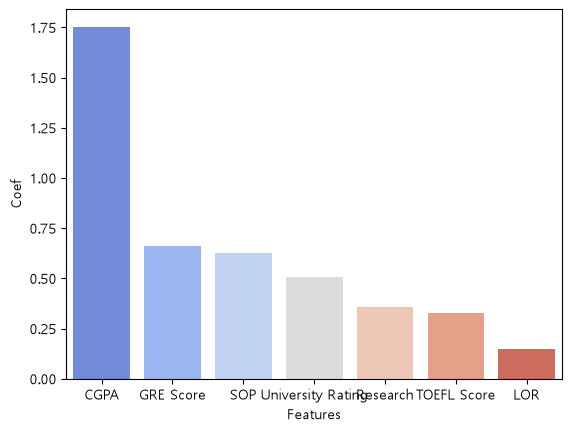

In [98]:
sns.barplot(coef_df, x="Features", y="Coef", palette="coolwarm", hue="Features")
plt.show()